In [1]:
import pandas as pd

In [2]:
import os

In [47]:
final = pd.read_csv(os.path.join('/arc/home/calvin/kko_host_paper','data_products/kko_full_cat.csv'))
final.set_index('chime_event_id',inplace=True)

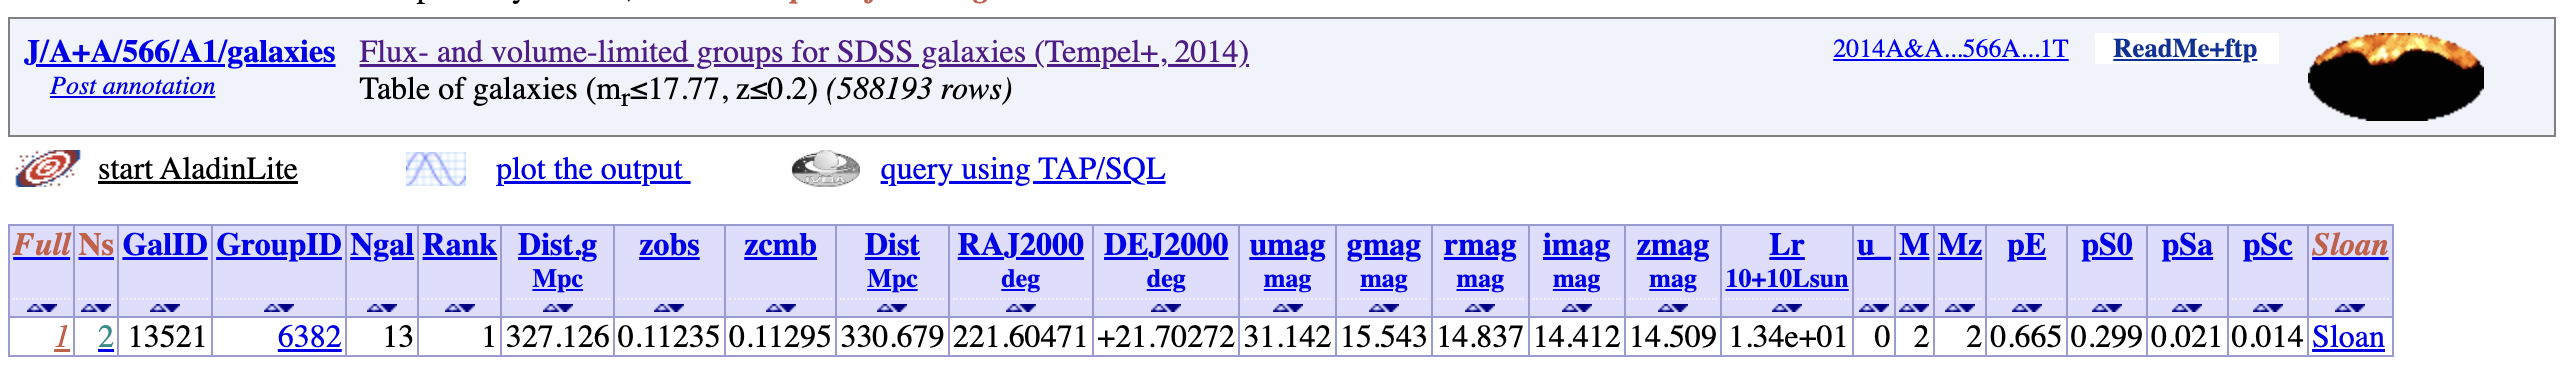

In [48]:
final.keys()

Index(['name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600', 'primary_id',
       'secondary_id', 'primary_ra', 'primary_dec', 'primary_P_Ox',
       'primary_z_phot_median', 'primary_z_phot_l95', 'primary_z_phot_u95',
       'primary_z_spec', 'primary_mag', 'secondary_ra', 'secondary_dec',
       'secondary_P_Ox', 'secondary_z_phot_median', 'secondary_z_phot_l95',
       'secondary_z_phot_u95', 'secondary_z_spec', 'secondary_mag',
       'primary_z_spec_source', 'dm_igm', 'extinction_mags', 'flux',
       'flux_err', 'fluence', 'fluence_err'],
      dtype='object')

In [4]:
final[final['name'] == 'FRB20231204A'][['primary_ra','primary_dec','DM','dm_igm','DM_YT20','DM_NE2001','primary_z_spec','primary_mag']]

,primary_ra,primary_dec,DM,dm_igm,DM_YT20,DM_NE2001,primary_z_spec,primary_mag
chime_event_id,,,,,,,,
342256558,207.999403,48.120566,222.0,53.942359,32.003043,29.8287,0.0644,15.397451


In [17]:
from astropy.coordinates import SkyCoord

In [100]:
coords_bhardwaj2024 = ['23h14m52s +48d20m25s',    '12h03m43s +27d33m09s',    '04h23m16s +16d04m02s',    '17h02m42s +21d34m35s']
scb =  SkyCoord(coords_bhardwaj2024,frame = 'icrs')
_bhardwaj2024 = {
    'name':   ['FRB20181220A', 'FRB20181223C', 'FRB20190418A', 'FRB20190425A'],
    'ra_frb': scb.ra.deg,
    'dec_frb': scb.dec.deg,
    'DM' : [209.4,112.5,184.5,128.2],
    'primary_z_spec': [0.0275, 0.0302, 0.0715, 0.0312],
    'M_r': [-19.71,-18.85, -20.93, -20.95]
}
bhardwaj2024 = pd.DataFrame(data = _bhardwaj2024)

In [101]:
import numpy as np
from scipy.optimize import minimize,approx_fprime



# Function to fit mu and sigma using MLE
def fit_mu_sigma(data):
    # Define the negative log-likelihood function for a normal distribution
    def neg_log_likelihood(params):
        mu, sigma = params
        # Avoid log(0) by ensuring sigma > 0
        if sigma <= 0:
            return np.inf
        # Compute the negative log-likelihood
        nll = -np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((data - mu) ** 2) / (2 * sigma**2))
        return nll
    def jac(params):
        """d logL / dmu, d logL / dsigma"""
        n = len(data)
        sigma = params[1]
        mu = params[0]
        dn_dmu = 1 / sigma**2 * np.sum(data - mu)
        dn_dsigma = -n / sigma + 1/sigma**3 * np.sum((data - mu)**2)
        return [-dn_dmu, -dn_dsigma]
    
    def hess(params):
        n = len(data)
        sigma = params[1]
        mu = params[0]
        dn_dmumu = - n / sigma**2
        dn_dmusigma = -2 / sigma**3 * np.sum(data - mu)
        dn_dsigsig = 2 * n / sigma**2 - 3 / sigma**4 * np.sum((data - mu)**2)
        return np.array([[-dn_dmumu, -dn_dmusigma],[-dn_dmusigma,-dn_dsigsig]])
        
    # Initial guesses for mu and sigma
    initial_guess = [np.mean(data), np.std(data)]
    
    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, initial_guess, method = 'Nelder-Mead', 
                       jac = jac,hess=hess)
    
    # Extract the fitted mu and sigma from the result
    mu_fit, sigma_fit = result.x
    #hessian_inv = result.hess_inv  # Inverse of the Hessian (covariance matrix)

    # Standard errors (square roots of the diagonal elements of the covariance matrix)
    #standard_errors = np.sqrt(np.diag(hessian_inv))
    hh = hess(result.x)
    unc= np.sqrt(np.diag(np.linalg.inv(hh)))
    return result.x,unc

import numpy as np
import matplotlib.pyplot as plt

/opt/pysetup/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:550: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  warn('Method %s does not use gradient information (jac).' % method,
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:555: RuntimeWarning: Method Nelder-Mead does not use Hessian information (hess).
  warn('Method %s does not use Hessian information (hess).' % method,


$\mu = 1.94 \pm 0.11$, $\sigma=0.40 \pm 0.13$
$\mu = 1.95 \pm 0.12$, $\sigma=0.40 \pm 0.13$
$\mu = 1.88 \pm 0.11$, $\sigma=0.40 \pm 0.18$


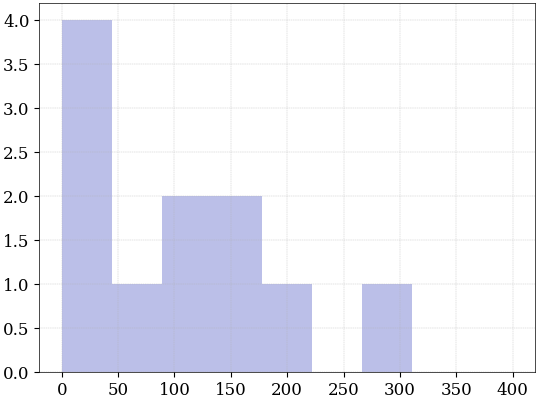

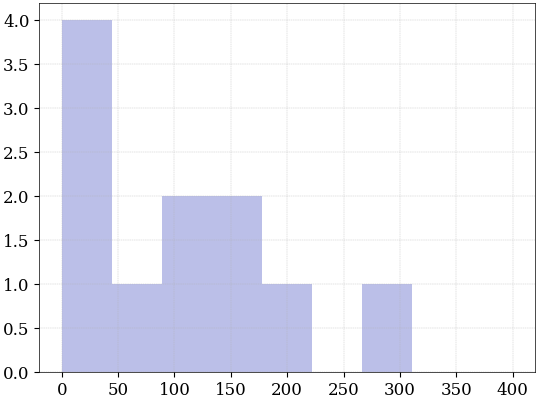

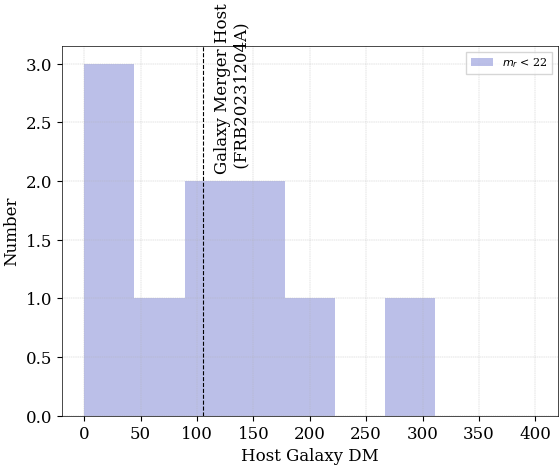

In [288]:
# Fiducial measurement: PATH P(O|x) > 0.9; m_r < 19.5; Use z_spec
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)
# Impact of relaxing PATH:
fiducial_lower_pox = (final['primary_P_Ox'] > 0.5) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)

fiducial_fainter_mag=(final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)

plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
bins = np.linspace(0,400,num = 10)
dm_host = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
plt.figure()
plt.hist(dm_host[fiducial_lower_pox],label = 'Lower P(O|x)',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial_fainter_mag],label = 'Fiducial',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial],label = '$m_r$ < 22',bins = bins,alpha = 0.3)
rest_frame_merger_dm = dm_host[final.index == 342256558].values / (1 + final['primary_z_spec'][final.index == 342256558].values)
plt.axvline(rest_frame_merger_dm,color = 'black',linestyle = '--')
plt.text(x = rest_frame_merger_dm + 10,y = 2.1,s = 'Galaxy Merger Host\n (FRB20231204A)',rotation = 90)
plt.legend()
plt.xlabel('Host Galaxy DM')
plt.ylabel('Number')
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_lower_pox]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_fainter_mag]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sigma:.2f} \pm {sig_err:.2f}$")
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi=100)

In [41]:
from scipy.interpolate import interp1d

In [44]:
from frb.dm import igm
z_interp = np.geomspace(0.001,1,num = 30)
dm_igm_interp = []
for ii, z_interp_i in enumerate(z_interp):
    dm_igm_interp.append(igm.average_DM(z_interp_i))
    print(ii,'/30')
dm_igm_interp= np.array([di.value for di in dm_igm_interp])

0 /30
1 /30
2 /30
3 /30
4 /30
5 /30
6 /30
7 /30
8 /30
9 /30
10 /30
11 /30
12 /30
13 /30
14 /30
15 /30
16 /30
17 /30
18 /30
19 /30
20 /30
21 /30
22 /30
23 /30
24 /30
25 /30
26 /30
27 /30
28 /30
29 /30


In [162]:
import numpy as np

import pandas as pd
import os
import json
from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u

import astropy.units as u
import pyne2001
import astropy.coordinates as coord
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

def get_ne2001(c_icrs,get_scatt = True):
    dm_ne2001 = np.zeros(len(c_icrs))
    tau600_ne2001 = np.zeros(len(c_icrs))

    for ii,(gl,gb) in enumerate(zip(c_icrs.galactic.l,c_icrs.galactic.b)):
        ne2001_pred = pyne2001.get_dm_full(gl.value,gb.value,dist_kpc = 100.0)
        #print(f"dist: {ne2001_pred['DIST']}")
        dm_ne2001[ii] = ne2001_pred['DM']
        tau600_ne2001[ii] = ne2001_pred['TAU'] * (1/0.6)**4
    if get_scatt:
        return dm_ne2001,tau600_ne2001
    else:
        return dm_ne2001
def calculate_halo_dm_yt20(l, b):
    coeffs = np.array(
        [
            [250.12, -871.06, 1877.5, -2553.0, 2181.3, -1127.5, 321.72, -38.905],
            [-154.82, 783.43, -1593.9, 1727.6, -1046.5, 332.09, -42.815, 0],
            [-116.72, -76.815, 428.49, -419.00, 174.60, -27.610, 0, 0],
            [216.67, -193.30, 12.234, 32.145, -8.3602, 0, 0, 0],
            [-129.95, 103.80, -22.800, 0.44171, 0, 0, 0, 0],
            [39.652, -21.398, 2.7694, 0, 0, 0, 0, 0],
            [-6.1926, 1.6162, 0, 0, 0, 0, 0, 0],
            [0.39346, 0, 0, 0, 0, 0, 0, 0],
        ]
    )
    l_absolute = np.abs(np.deg2rad(l))
    b_absolute = np.abs(np.deg2rad(b))
    DM_halo = 0
    for ii in range(8):
        for jj in range(8):
            DM_halo += coeffs[ii, jj] * l_absolute ** ii * b_absolute ** jj
    return DM_halo # u.pc / u.cm ** 3

# Load in final ellipse catalog
# Add galactic DM & tau

from astropy.coordinates import SkyCoord

c_icrs = SkyCoord(ra=bhardwaj2024['ra_frb'].values,
                  dec=bhardwaj2024['dec_frb'].values,unit = 'deg',frame = 'icrs') # baseband position

dm_ne2001, tau600_ne2001 = get_ne2001(c_icrs,get_scatt = True)
dm_yt20 = calculate_halo_dm_yt20(l = c_icrs.galactic.l.deg, b= c_icrs.galactic.b.deg)

bhardwaj2024.insert(loc = 5, column = 'DM_NE2001',value = dm_ne2001,allow_duplicates = False)
bhardwaj2024['tau_NE2001_600'] = tau600_ne2001
bhardwaj2024.insert(loc = 5, column = 'DM_YT20',value = dm_yt20,allow_duplicates = False)
bhardwaj2024.insert(loc = 5, column = 'gal_l', value = c_icrs.galactic.l.deg)
bhardwaj2024.insert(loc = 5, column = 'gal_b', value = c_icrs.galactic.b.deg)


ValueError: cannot insert DM_NE2001, already exists

In [163]:
dsa_110_frbs = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/dsa_110_published.csv',
    names= ['name','MJD', 'DM','Width','SNR','ra_frb','dec_frb','poserr','Name','primary_z_spec'],
                           skiprows = 1)

coord_dsa = coord.SkyCoord(dsa_110_frbs['ra_frb'].values,dsa_110_frbs['dec_frb'].values,unit = 'deg',frame='icrs')
dsa_110_frbs.insert(loc = 5, column = 'gal_l', value = coord_dsa.galactic.l.deg)
dsa_110_frbs.insert(loc = 5, column = 'gal_b', value = coord_dsa.galactic.b.deg)
dm_ne2001, tau600_ne2001 = get_ne2001(coord_dsa,get_scatt = True)
dm_yt20 = calculate_halo_dm_yt20(l = coord_dsa.galactic.l.deg, b= coord_dsa.galactic.b.deg)
dsa_110_frbs.insert(loc = 5, column = 'DM_NE2001',value = dm_ne2001,allow_duplicates = False)
dsa_110_frbs['tau_NE2001_600'] = tau600_ne2001
dsa_110_frbs.insert(loc = 5, column = 'DM_YT20',value = dm_yt20,allow_duplicates = False)
dsa_110_frbs['M_r'] = np.array([-20.2, -19.97, -20.79, -20.23, -20.88, -20.63, -21.34, -19.46, -18.31, -19.96, -20.94])

In [175]:
dsa_110_frbs.set_index('name')
bhardwaj2024.set_index('name')

,ra_frb,dec_frb,DM,primary_z_spec,gal_b,gal_l,DM_YT20,DM_NE2001,M_r,tau_NE2001_600,dm_igm,DM_host_restframe
name,,,,,,,,,,,,
FRB20181220A,348.716667,48.340278,209.4,0.0275,-11.488166,106.824998,42.637559,118.4717,-19.71,0.015640,22.823994,24.785156
FRB20181223C,180.929167,27.552500,112.5,0.0302,79.397982,207.900247,59.079139,19.9345,-18.85,0.000294,25.084044,8.156006
FRB20190418A,65.816667,16.067222,184.5,0.0715,-22.892038,179.296728,31.674712,70.2136,-20.93,0.003414,59.994433,21.108031
FRB20190425A,255.675000,21.576389,128.2,0.0312,33.078687,42.103904,48.573220,48.6850,-20.95,0.002044,25.921698,4.868194


In [176]:
def calc_dm_igm(final,source = 'zphot'):
    from frb.dm import igm
    for evid,row in final.iterrows():
        if source == 'zphot': 
            best_redshift = row['primary_z_phot_median']
        elif source == 'zspec':
            best_redshift = row['primary_z_spec']
        elif source == 'mix':
            if row['primary_z_spec'] > 0:
                best_redshift = row['primary_z_spec']
            elif row['primary_z_phot_median'] > 0:
                best_redshift = row['primary_z_phot_median']
            else:
                best_redshift = -1
        if best_redshift > 0:
            dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = best_redshift)
            final.at[evid,'dm_igm'] = dm_igm
        else:
            final.at[evid,'dm_igm'] = np.nan
    return final
def calc_dmh(final):
    dmh = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
    final['DM_host_restframe'] = dmh
    return dmh

In [ ]:
dsa_110_frbs

,name,MJD,DM,Width,SNR,DM_YT20,DM_NE2001,gal_b,gal_l,ra_frb,dec_frb,poserr,Name,primary_z_spec,tau_NE2001_600,M_r,dm_igm,DM_host_restframe
0,220319aaeb,59657.932757,110.950000,0.160000,79.00000,39.411301,139.7375,9.107061,129.182988,32.177917,71.035000,0.600,FRB 20220319D or Mark,0.011228,0.034684,-20.20,9.279008,-76.617547
1,220914aabz,59836.145966,630.703000,0.524288,9.64463,36.881244,54.6831,26.130106,104.308037,282.056792,73.336914,0.930,FRB 20220914A or Elektra,0.113900,0.002394,-19.97,96.502866,397.374801
2,220426aaaw,59708.494499,270.260000,0.524288,21.50750,37.690038,55.6079,25.476401,100.943194,282.670000,70.243833,2.200,FRB 20220509G or Jackie,0.089400,0.002504,-20.79,75.331754,93.290168
3,220207aabh,59617.808504,263.000000,0.524288,59.96350,39.224429,76.0997,18.389592,106.938497,310.199525,72.882327,0.630,FRB 20220207C or Zach,0.043040,0.005127,-20.23,35.865547,107.196583
4,220307aaae,59645.845634,499.328000,0.524288,11.90590,41.099177,128.2243,10.471797,116.245945,350.874496,72.192386,1.720,FRB 20220307B or Alex,0.248123,0.021736,-20.88,215.676818,91.599710
5,220310aaam,59648.241721,462.657000,1.048576,68.41000,31.136122,46.3394,34.798014,140.024371,134.720500,73.490833,1.900,FRB 20220310F or Whitney,0.477958,0.001470,-20.63,427.998315,-28.970267
6,220418aaai,59687.355728,624.124000,1.048576,10.87820,32.315488,36.6542,44.467169,110.753091,219.105575,70.095944,1.356,FRB 20220418A or Quincy,0.622000,0.000914,-21.34,563.821874,-5.343749
7,220506aabd,59705.597013,396.651000,0.524288,48.91870,39.746473,84.5563,16.513444,108.354410,318.044833,72.827278,1.110,FRB 20220506D or Oran,0.300390,0.006542,-19.46,263.203348,7.032413
8,220825aaad,59816.257292,649.893000,1.048576,15.06450,39.467305,78.4804,17.785247,106.994993,311.981450,72.584969,0.780,FRB 20220825A or Ansel,0.241397,0.005512,-18.31,209.560848,259.694881
9,220920aacl,59842.981571,314.976978,0.524288,14.35070,33.684480,39.8597,38.893321,104.923127,240.257083,70.918800,1.020,FRB 20220920A or Etienne,0.158239,0.001131,-19.96,135.335637,91.602131


In [177]:
# Bhardwaj
calc_dm_igm(bhardwaj2024,source='zspec')
calc_dmh(bhardwaj2024)

# DSA
calc_dm_igm(dsa_110_frbs,source = 'zspec')
calc_dmh(dsa_110_frbs)

# Leung
final_zspec = calc_dm_igm(final,source = 'zspec')
final_zphot = calc_dm_igm(final,source = 'zphot')
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)
calc_dmh(final_zspec)
calc_dmh(final_zphot)

#[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zspec[fiducial]))
#print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sig:.3f} \pm {sig_err:.3f}$")
#[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zphot[fiducial]))
#print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sig:.3f} \pm {sig_err:.3f}$")


chime_event_id
335002503           inf
348570237          -inf
325140573     26.244328
331641308          -inf
326033351          -inf
                ...    
337199498           inf
325442526     20.479645
325287323    380.860790
321637098    242.787154
347043008    204.530946
Length: 83, dtype: float64

In [178]:
from astropy.cosmology import Planck18

In [187]:
def calc_Mr(final,source='zspec'):
    if source == 'zspec':
        dist_mod = Planck18.distmod(np.clip(final['primary_z_spec'].values,a_min = 0,a_max = np.inf)).value
    if source == 'zphot':
        dist_mod = Planck18.distmod(np.clip(final['primary_z_phot'].values,a_min = 0,a_max = np.inf)).value
    final['M_r'] = final['primary_mag'] - final['extinction_mags'] - dist_mod

In [180]:
def label_above_dmh(df,thres = 200):
    for name,row in df.iterrows():
        if row['DM_host_restframe'] > thres:
            plt.text(x = row['M_r'], y = row['DM_host_restframe'], s = name)
    

In [192]:
dsa_110_frbs,dsa_110_frbs['DM_host_restframe']

(          name           MJD          DM     Width       SNR    DM_YT20   
 0   220319aaeb  59657.932757  110.950000  0.160000  79.00000  39.411301  \
 1   220914aabz  59836.145966  630.703000  0.524288   9.64463  36.881244   
 2   220426aaaw  59708.494499  270.260000  0.524288  21.50750  37.690038   
 3   220207aabh  59617.808504  263.000000  0.524288  59.96350  39.224429   
 4   220307aaae  59645.845634  499.328000  0.524288  11.90590  41.099177   
 5   220310aaam  59648.241721  462.657000  1.048576  68.41000  31.136122   
 6   220418aaai  59687.355728  624.124000  1.048576  10.87820  32.315488   
 7   220506aabd  59705.597013  396.651000  0.524288  48.91870  39.746473   
 8   220825aaad  59816.257292  649.893000  1.048576  15.06450  39.467305   
 9   220920aacl  59842.981571  314.976978  0.524288  14.35070  33.684480   
 10  221012aaab  59864.051091  440.357705  2.097152   9.41028  37.430238   
 
     DM_NE2001      gal_b       gal_l      ra_frb    dec_frb  poserr   
 0    139.7375

In [193]:
dsa_110_frbs

,name,MJD,DM,Width,SNR,DM_YT20,DM_NE2001,gal_b,gal_l,ra_frb,dec_frb,poserr,Name,primary_z_spec,tau_NE2001_600,M_r,dm_igm,DM_host_restframe
0,220319aaeb,59657.932757,110.950000,0.160000,79.00000,39.411301,139.7375,9.107061,129.182988,32.177917,71.035000,0.600,FRB 20220319D or Mark,0.011228,0.034684,-20.20,9.279008,-76.617547
1,220914aabz,59836.145966,630.703000,0.524288,9.64463,36.881244,54.6831,26.130106,104.308037,282.056792,73.336914,0.930,FRB 20220914A or Elektra,0.113900,0.002394,-19.97,96.502866,397.374801
2,220426aaaw,59708.494499,270.260000,0.524288,21.50750,37.690038,55.6079,25.476401,100.943194,282.670000,70.243833,2.200,FRB 20220509G or Jackie,0.089400,0.002504,-20.79,75.331754,93.290168
3,220207aabh,59617.808504,263.000000,0.524288,59.96350,39.224429,76.0997,18.389592,106.938497,310.199525,72.882327,0.630,FRB 20220207C or Zach,0.043040,0.005127,-20.23,35.865547,107.196583
4,220307aaae,59645.845634,499.328000,0.524288,11.90590,41.099177,128.2243,10.471797,116.245945,350.874496,72.192386,1.720,FRB 20220307B or Alex,0.248123,0.021736,-20.88,215.676818,91.599710
5,220310aaam,59648.241721,462.657000,1.048576,68.41000,31.136122,46.3394,34.798014,140.024371,134.720500,73.490833,1.900,FRB 20220310F or Whitney,0.477958,0.001470,-20.63,427.998315,-28.970267
6,220418aaai,59687.355728,624.124000,1.048576,10.87820,32.315488,36.6542,44.467169,110.753091,219.105575,70.095944,1.356,FRB 20220418A or Quincy,0.622000,0.000914,-21.34,563.821874,-5.343749
7,220506aabd,59705.597013,396.651000,0.524288,48.91870,39.746473,84.5563,16.513444,108.354410,318.044833,72.827278,1.110,FRB 20220506D or Oran,0.300390,0.006542,-19.46,263.203348,7.032413
8,220825aaad,59816.257292,649.893000,1.048576,15.06450,39.467305,78.4804,17.785247,106.994993,311.981450,72.584969,0.780,FRB 20220825A or Ansel,0.241397,0.005512,-18.31,209.560848,259.694881
9,220920aacl,59842.981571,314.976978,0.524288,14.35070,33.684480,39.8597,38.893321,104.923127,240.257083,70.918800,1.020,FRB 20220920A or Etienne,0.158239,0.001131,-19.96,135.335637,91.602131


In [241]:
final_zspec.loc[339589360]

name                                                            FRB20231128A
ra_frb                                                            199.578201
dec_frb                                                            42.992708
b_err                                                               0.000556
a_err                                                               0.008303
gal_b                                                              73.224004
gal_l                                                             105.685235
DM_YT20                                                            31.323608
DM_NE2001                                                            25.0063
theta                                                               9.904936
tags                                                               CHIME-KKO
frb_survey                                                         CHIME/FRB
DM                                                                     332.4

In [242]:
exclude = (final_zspec['name'] == 339589360) + (final_zspec['name'] == 342760050)

In [ ]:
325140573	246.027572	35.446989 - 82,1
342256558	207.999403	48.120566 - omit, double
339589360	199.580129	42.999713 - too faint
347082860	259.544432	29.495848 - 49, 1
330976597	270.786050	63.985568 - unresolved
330838705	71.974285	33.237527 - outside SDSS
328261629	346.753314	36.648447 - outside
321977347	269.124186	41.809999 - 73, 1
338403209	82.622632	4.474384 - outside
341758878	65.030607	38.632866 - outside
341477821	54.587601	26.812848 - outside
326456063	18.241706	41.748995 - outside
300938875	184.622792	48.725034 - irregular
306528286	54.664905	33.160664 - outside
268786306	151.663820	35.697150 - 77, 1
272350056	106.960492	11.222877 - outside
272367619	238.737954	30.899874 - 48, 0
342760050	112.443123	56.253245 - outside
325442526	307.529411	72.887196 - outside

In [245]:
final_zspec[final_zspec['primary_P_Ox'] > 0.9][['name','primary_ra','primary_dec']]

,name,primary_ra,primary_dec
chime_event_id,,,
325140573,FRB20231005A,246.027572,35.446989
342256558,FRB20231204A,207.999403,48.120566
339589360,FRB20231128A,199.580129,42.999713
347082860,FRB20231223C,259.544432,29.495848
330976597,FRB20231025B,270.786050,63.985568
330838705,FRB20231025C,71.974285,33.237527
328261629,FRB20231017A,346.753314,36.648447
321977347,FRB20230926A,269.124186,41.809999
338403209,FRB20231123A,82.622632,4.474384


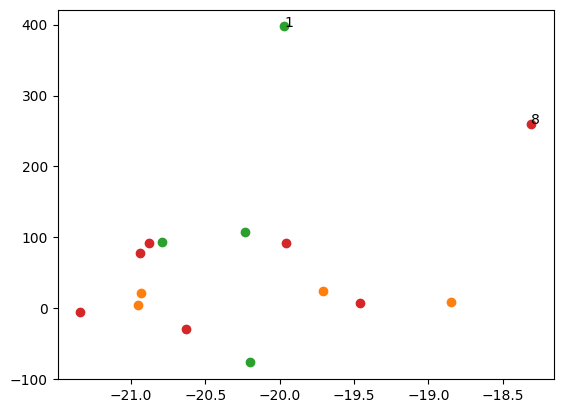

In [243]:
dsa_110_frbs.set_index('name')
plt.figure()
plt.scatter((final_zspec['M_r'])[fiducial * exclude],final_zspec['DM_host_restframe'][fiducial * exclude])
label_above_dmh(final_zspec[fiducial * exclude],150)
plt.scatter(bhardwaj2024['M_r'],bhardwaj2024['DM_host_restframe'])
dsa_lowz = dsa_110_frbs['primary_z_spec'] < 0.15
plt.scatter(dsa_110_frbs['M_r'][dsa_lowz],dsa_110_frbs['DM_host_restframe'][dsa_lowz])
label_above_dmh(dsa_110_frbs,150)
plt.scatter(dsa_110_frbs['M_r'][~dsa_lowz],dsa_110_frbs['DM_host_restframe'][~dsa_lowz])


In [201]:
import re

In [238]:
latex_table = r"""
1 & FRB20121102A & 0.1927 & y & $0.8 \pm0.1$ & $0.66\pm0.03$ & $0.01 \pm0.01$ & $0.15 \pm0.04$ & $-$8.99 & $-16.20 \pm0.08$ & $1.49 \pm0.18$  & 8.08  \\
2 & FRB20180301A & 0.3304 & y & $10.2 \pm3.0$ & $5.80 \pm 0.20$ & $0.23 \pm0.06$ & $1.93 \pm0.58$ & $-$9.08 & $-20.18 \pm0.07$ & $0.90 \pm0.11$  & 8.70  \\
3 & FRB20180916B & 0.0337 & y & $5.4 \pm0.0$ & $3.57\pm 0.36$& $0.22 \pm0.03$ & $0.06 \pm0.02$ & $-$10.58 & $-19.46 \pm0.05$ & $1.53 \pm0.06$  &  -  \\
4 & FRB20180924B & 0.3212 & n & $3.4 \pm0.8$ & $2.75\pm 0.10$ &$1.32 \pm0.51$ & $0.88 \pm0.26$ & $-$10.18 & $-20.81 \pm0.05$ & $1.78 \pm0.15$  & 8.93  \\
5 & FRB20190102C & 0.2912 & n & $2.3 \pm4.2$ & $4.43 \pm 0.51$ &$0.47 \pm0.54$ & $0.86 \pm0.26$ & $-$9.74 & $-19.87 \pm0.06$ & $1.44 \pm0.15$  & 8.70  \\
6 & FRB20190608B & 0.1178 & n & $6.5 \pm0.8$ & $2.84 \pm 0.23$ &$1.16 \pm0.28$ & $0.69 \pm0.21$ & $-$10.22 & $-21.22 \pm0.05$ & $1.40 \pm0.09$  & 8.85  \\
7 & FRB20190611B & 0.3778 & n & $11.7 \pm5.8$ & $2.15 \pm 0.11$ &$0.35 \pm0.70$ & $0.27 \pm0.08$ & $-$10.11 & $-19.29 \pm0.10$ & $1.29 \pm0.18$  & 8.71  \\
8 & FRB20190711A & 0.5220 & y & $1.6 \pm4.5$ & $2.94\pm 0.17$ &$ 0.08 \pm0.03$ & $0.42 \pm0.12$ & $-$9.29 & $-19.01 \pm0.08$ & $0.95 \pm0.16$  &  -  \\
9 & FRB20190714A & 0.2365 & n & $2.7 \pm1.8$ & $3.94\pm 0.05$ &$1.42 \pm0.55$ & $0.65 \pm0.20$ & $-$10.34 & $-20.37 \pm0.05$ & $1.51 \pm0.28$  & 9.03  \\
10 & FRB20191001A & 0.2340 & n & $11.1 \pm0.8$ & $5.55\pm 0.03$ & $4.64 \pm1.88$ & $8.06 \pm2.42$ & $-$9.76 & $-22.13 \pm0.05$ & $1.67 \pm0.19$  & 8.94  \\
11 & FRB20191228A & 0.2432 & n & $5.7 \pm3.3$ & $1.78 \pm 0.06$ & $0.54 \pm0.60$ & $0.50 \pm0.15$ & $-$10.03 & $-18.26 \pm0.05$ & $2.13 \pm0.74$  & 8.48 \\
12 & FRB20200430A & 0.1608 & n & $1.7 \pm2.2$ & $1.64 \pm 0.53$ & $0.21 \pm0.11$ & $0.26 \pm0.08$ & $-$9.89 & $-18.25 \pm0.05$ & $2.08 \pm0.30$  & 8.88  \\
13 & FRB20200906A & 0.3688 & n & $5.9 \pm2.0$ & $7.58 \pm 0.06$ & $1.33 \pm0.37$ & $0.48 \pm0.14$ & $-$10.44 & $-21.49 \pm0.05$ & $1.22 \pm0.11$  & 8.76  \\
14 & FRB20171020A & 0.0087 & n &  - & - & 0.09 & 0.13 & $-$9.84 & $-$17.9  & - & 8.30 \\
15 & FRB20200120E & 0.0008 & y & $20.1 \pm3.0$ & 3.5 & $7.20 \pm1.70$ & $0.89 \pm0.27$ & $-$10.91 & $-$19.78  & $2.77 \pm0.00$ & - \\
16 & FRB20201124A & 0.0980 & y & $1.3\pm0.1$ & - & $1.70^{+0.08}_{-0.11}$ & $2.12^{+0.69}_{-0.28}$ & $-$9.90 & $-20.41 \pm0.03$ & $2.06 \pm0.55$  & 9.03 \\
17 & FRB20190523A & 0.6600 & n & $27.2 \pm22.6$ & $3.28 \pm 0.18$ & $46.49 \pm35.51$ & $0.09 \pm0.03$ & $-$12.74 & $-22.69 \pm0.14$ & $2.20 \pm0.22$  &  -  \\
"""

# Remove uncertainties and dollar signs, replace missing cells with NaN
def clean_row(row):
    # Remove uncertainties, dollar signs, and trim spaces
    row = re.sub(r'\$[^\$]+\$', lambda x: x.group(0).split('\pm')[0].replace('$', '').strip(), row)
    row = re.sub(r'\$', '', row)  # Remove remaining dollar signs
    # Handle negative numbers correctly, replacing isolated ' - ' with NaN
    row = row.replace(' - ', ' np.nan ')
    return row
# Split the LaTeX table into rows
rows = latex_table.split("\\\\")

# Column names
columns = ["name", "primary_z_spec", "repeater", "offset_kpc", "R_eff_kpc", "mass_10", "sfr", "log_ssfr", "M_r", "u_minus_r", "metallicity"]

# Data container
data = []

# Parse each row and clean
for row in rows:
    row = clean_row(row)
    # Split by '&' and ignore the first index column
    items = row.split("&")[1:]
    items = [item.strip() for item in items]  # Remove leading/trailing spaces
    data.append(items)

# Create DataFrame and replace missing values with np.nan
df = pd.DataFrame(data, columns=columns)
df.replace({"np.nan": np.nan}, inplace=True)
df.set_index('name')
# Output the DataFrame

,primary_z_spec,repeater,offset_kpc,R_eff_kpc,mass_10,sfr,log_ssfr,M_r,u_minus_r,metallicity
name,,,,,,,,,,
FRB20121102A,0.1927,y,0.8,0.66,0.01,0.15,-8.99,-16.20,1.49,8.08
FRB20180301A,0.3304,y,10.2,5.80,0.23,1.93,-9.08,-20.18,0.90,8.70
FRB20180916B,0.0337,y,5.4,3.57,0.22,0.06,-10.58,-19.46,1.53,NaN
FRB20180924B,0.3212,n,3.4,2.75,1.32,0.88,-10.18,-20.81,1.78,8.93
FRB20190102C,0.2912,n,2.3,4.43,0.47,0.86,-9.74,-19.87,1.44,8.70
FRB20190608B,0.1178,n,6.5,2.84,1.16,0.69,-10.22,-21.22,1.40,8.85
FRB20190611B,0.3778,n,11.7,2.15,0.35,0.27,-10.11,-19.29,1.29,8.71
FRB20190711A,0.5220,y,1.6,2.94,0.08,0.42,-9.29,-19.01,0.95,NaN
FRB20190714A,0.2365,n,2.7,3.94,1.42,0.65,-10.34,-20.37,1.51,9.03


347261948
319829796


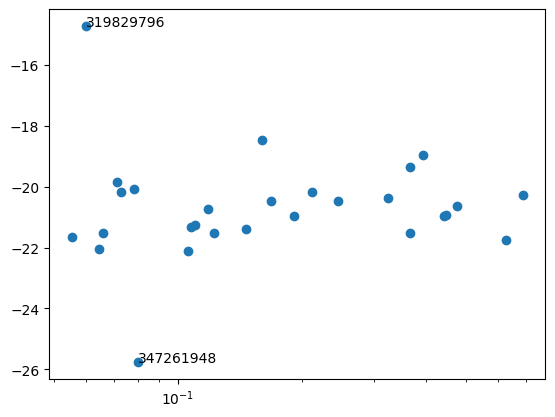

In [182]:
plt.figure()
plt.scatter(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod)
for x,y,s in zip(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod,final.index):
    if (y > -16 or y < -23) and x > 0:
        print(s)
        plt.text(x,y,s=s)
plt.xscale('log')

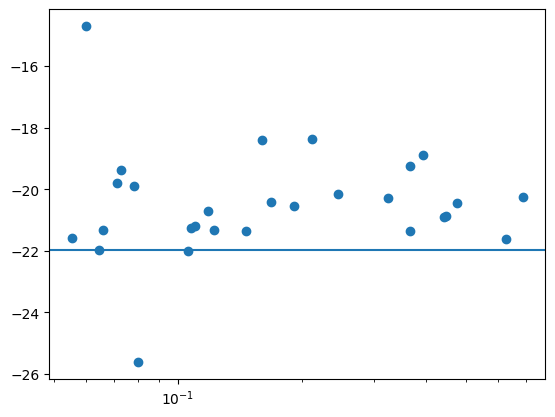

In [183]:
plt.figure()
plt.scatter(final['primary_z_spec'],final['primary_mag'] - dist_mod)
plt.axhline((final['primary_mag'] - dist_mod).loc[342256558])
plt.xscale('log')